<a href="https://colab.research.google.com/github/honeylouluzon/Guided-Project-AI-ML-DataScience/blob/main/Shallow_Neural_Network_with_the_Sequential_API_of_Tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Shallow Neural Network with the Sequential API of TensorFlow

In [ ]:
#Needed imports
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import r2_score


##Dataset

In [ ]:
#Dataset preparation
sns.get_dataset_names()


['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [ ]:
#Creating dataframe
df = sns.load_dataset('mpg')
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'name'],
      dtype='object')

The **mpg dataset** is an automobile-related dataset and a description of each of its columns is given below:

**mpg**: miles per gallon of fuel. (continuous variable)

**cylinders**: number of engine cylinders. (discrete variable)

**displacement**: measure of the engine size. (continuous variable)

**horsepower**: the power produced by the engine. (continuous variable)

**weight**: weight of the car. (continuous variable)

**acceleration**: the acceleration rate of the car (continuous variable)

**model_year**: the year the model was released, from 1970 to 1982. (discrete variable)

**origin**: place of manufacturing. (categorical variable)

**name**: car model name. (unique for each instance)

In [ ]:
print(df.shape)

(398, 9)


The dataset has **398** *observations* (rows) and **9** *variables* (columns)

In [ ]:
df['mpg'].describe(include='all')

,mpg
count,398.000000
mean,23.514573
std,7.815984
min,9.000000
25%,17.500000
50%,23.000000
75%,29.000000
max,46.600000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [ ]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [ ]:
#MPG Acceleration Stat
stats = df['mpg'].describe(include='acceleration')
print(stats)



count    398.000000
mean      23.514573
std        7.815984
min        9.000000
25%       17.500000
50%       23.000000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64


In [ ]:
#Get the IQR
# Access 25% and 75%
Q1 = stats['25%']
Q3 = stats['75%']

print(f"25% (Q1): {Q1}")
print(f"75% (Q3): {Q3}")

# Compute IQR
IQR = Q3 - Q1
print(f"IQR: {IQR}")

25% (Q1): 17.5
75% (Q3): 29.0
IQR: 11.5


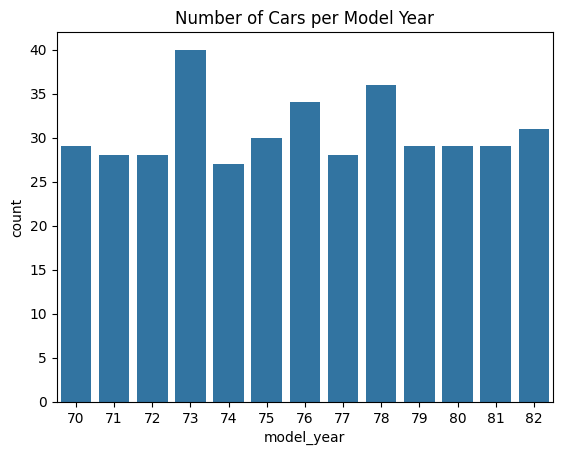

In [ ]:
#Categorical Data
sns.countplot(data=df, x="model_year")
plt.title("Number of Cars per Model Year")
plt.show()

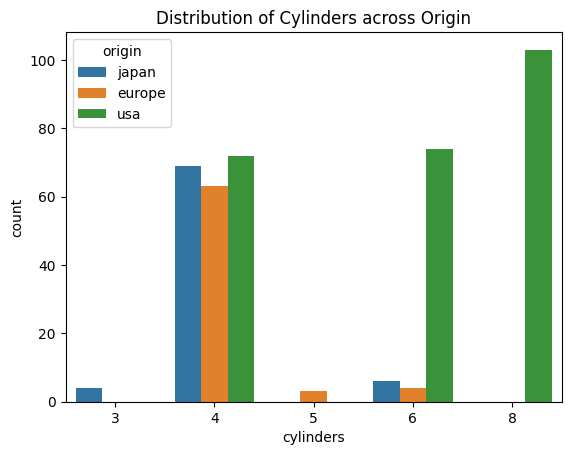

In [ ]:
sns.countplot(data=df, x='cylinders', hue='origin')
plt.title('Distribution of Cylinders across Origin')
plt.show()

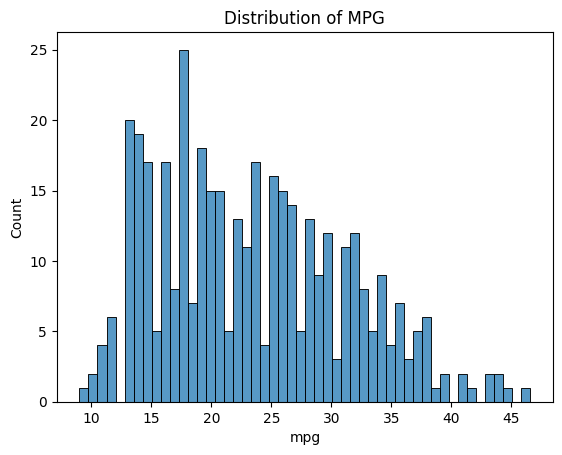

In [ ]:
sns.histplot(data=df, x="mpg", bins=50).set(title="Distribution of MPG", ylabel="Count")
plt.show()

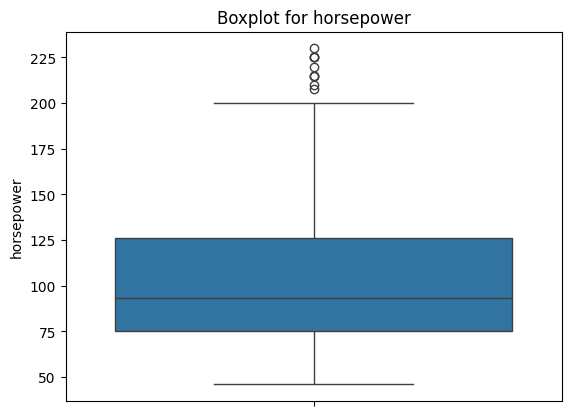

In [ ]:
sns.boxplot(data=df, y="horsepower")
plt.title("Boxplot for horsepower")
plt.show()

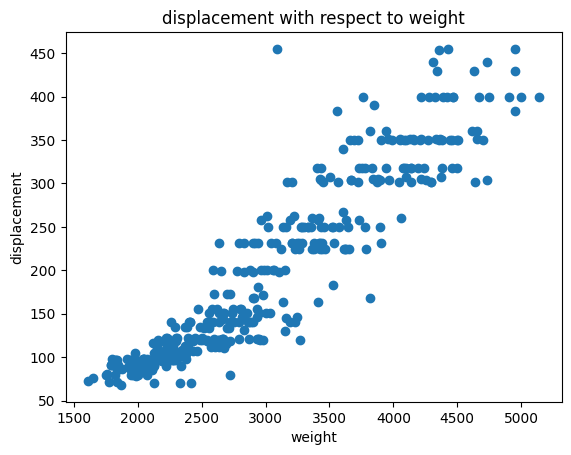

In [ ]:
plt.scatter(data=df, x="weight", y="displacement")
plt.title("displacement with respect to weight")
plt.ylabel("displacement")
plt.xlabel("weight")
plt.show()

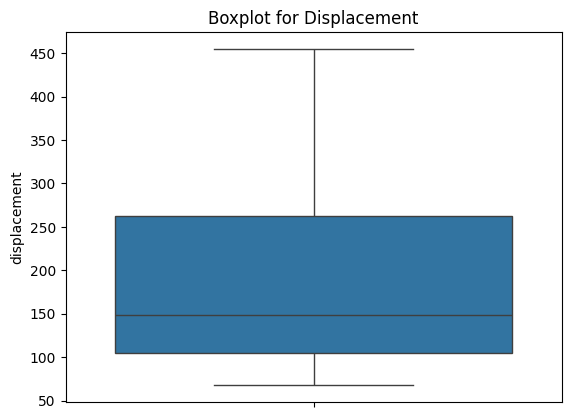

In [ ]:
sns.boxplot(data=df, y="displacement")
plt.title("Boxplot for Displacement")
plt.show()

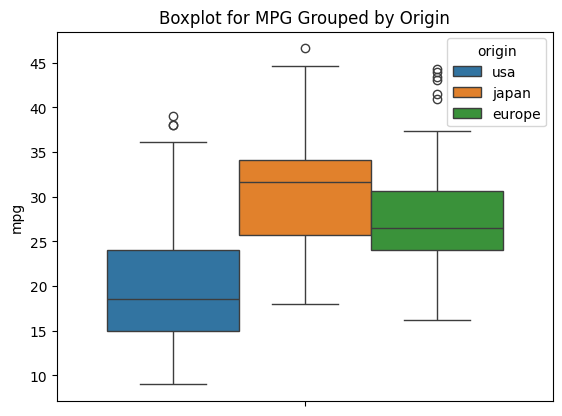

In [ ]:
sns.boxplot(data=df, y="mpg", hue="origin")
plt.title("Boxplot for MPG Grouped by Origin")
plt.show()

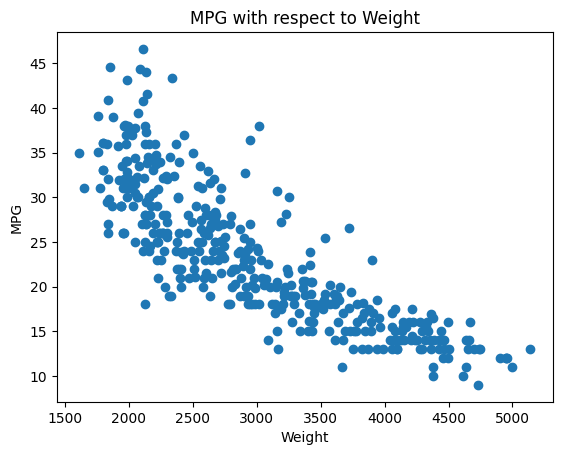

In [ ]:
plt.scatter(data=df, x="weight", y="mpg")
plt.title("MPG with respect to Weight")
plt.ylabel("MPG")
plt.xlabel("Weight")
plt.show()

##Data Cleaning

In [ ]:
#Checking Null Value
df.isna().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
name,0


In [ ]:
#Imputation or replacing missing calues
df['horsepower'].fillna(df['horsepower'].mean(), inplace=True)
df.isna().sum()

/tmp/ipython-input-2814498405.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(df['horsepower'].mean(), inplace=True)


,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0
origin,0
name,0


In [ ]:
df['name'].describe()

,name
count,398
unique,305
top,ford pinto
freq,6


In [ ]:
df.drop(['name'],axis=1, inplace=True)



In [ ]:
print(df.shape)

(398, 8)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
dtypes: float64(4), int64(3), object(1)
memory usage: 25.0+ KB


In [ ]:
print(df['mpg'].skew())
print(df['horsepower'].skew())
print(df['displacement'].skew())
print(df['weight'].skew())
print(df['acceleration'].skew())

0.45706634399491913
1.0955524807071189
0.7196451643005952
0.5310625125994629
0.27877684462588986


In [ ]:
#Outlier Removal - Using IQR Value

q1 = df['mpg'].quantile(q=0.25)
q3 = df['mpg'].quantile(q=0.75)
iqr = q3 - q1
lower = (q1 - 1.5 * iqr)
upper = (q3 + 1.5 * iqr)

In [ ]:
df['mpg'].clip(lower, upper)

,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0
...,...
393,27.0
394,44.0
395,32.0
396,28.0


In [ ]:
df = pd.get_dummies(df, columns=['origin'], drop_first=True, prefix='Origin')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   Origin_japan  398 non-null    bool   
 8   Origin_usa    398 non-null    bool   
dtypes: bool(2), float64(4), int64(3)
memory usage: 22.7 KB


In [ ]:
df['horsepower'] = df['horsepower'].clip(upper=200)


In [ ]:
df = pd.get_dummies(df, columns=['model_year','cylinders'], drop_first=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   mpg            398 non-null    float64
 1   displacement   398 non-null    float64
 2   horsepower     398 non-null    float64
 3   weight         398 non-null    int64  
 4   acceleration   398 non-null    float64
 5   Origin_japan   398 non-null    bool   
 6   Origin_usa     398 non-null    bool   
 7   model_year_71  398 non-null    bool   
 8   model_year_72  398 non-null    bool   
 9   model_year_73  398 non-null    bool   
 10  model_year_74  398 non-null    bool   
 11  model_year_75  398 non-null    bool   
 12  model_year_76  398 non-null    bool   
 13  model_year_77  398 non-null    bool   
 14  model_year_78  398 non-null    bool   
 15  model_year_79  398 non-null    bool   
 16  model_year_80  398 non-null    bool   
 17  model_year_81  398 non-null    bool   
 18  model_year

##Train and Test Sets Creation for Model Building

In [ ]:
target_variable = ['mpg']
predictors = list(set(list(df.columns)) - set(target_variable))

In [ ]:
df[predictors] = df[predictors] / df[predictors].max()

In [ ]:
df['acceleration'].describe()

,acceleration
count,398.000000
unique,95.000000
top,0.584677
freq,23.000000


In [ ]:
from sklearn.model_selection import train_test_split

X = df[predictors].values
y = df[target_variable].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=100)
print(X_train.shape); print(X_test.shape)

(278, 22)
(120, 22)


##Defining the Sequential API Model

In [ ]:
#Defining the model
model = tf.keras.Sequential(name='sequential')


In [ ]:
#Defining the layer of the model
model.add(tf.keras.layers.Dense(32, input_shape=(X_train.shape[1],), activation='relu'))
model.add(tf.keras.layers.Dense(1))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

##Compile the Model

We need to compile the model before it can be trained. Compiling a model requires us to specify an optimizer and a loss function.

###Optimizer

We will use Adam for this model. **Adam** is an extension of the well-known stochastic gradient descent (SGD) algorithm. **SGD** is a simple and efficient approach to minimizing an objective function that has smooth, bounded gradients. However, SGD can be difficult to use when training deep neural networks because it requires careful tuning of the learning rate.

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

###Loss Function

In [ ]:
model.compile(loss='loss function', metrics=['metrics'], optimizer=optimizer)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

##Train the Model on Train and Test Set

In [ ]:
# Explicitly cast X_train and y_train to float32 to ensure numerical dtype
X_train_casted = X_train.astype(np.float32)
y_train_casted = y_train.astype(np.float32)

model.fit(X_train_casted, y_train_casted, epochs=150, verbose=0)

##Evaluate the Model

In [ ]:
model.evaluate(X_train_casted, y_train_casted)




9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 13.7107 - mean_absolute_error: 2.8795 


[14.83408260345459, 3.0044572353363037]

In [ ]:
pred_train = model.predict(X_train_casted)
r_squared_value = r2_score(y_train_casted, pred_train)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


##Visualize the Result

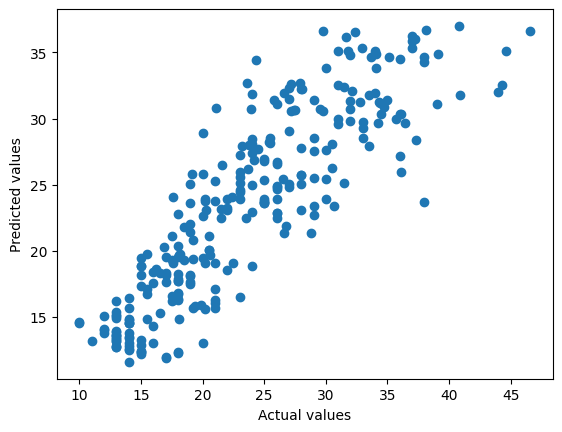

In [ ]:
plt.scatter(y_train, pred_train)
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.show()